In [48]:
import importlib
import solver
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [49]:
# Initial Conditions: split into two regions by initial discontinuity
WL = {"rho":1.0,   "u":0.0, "p":100000.0}
WR = {"rho":0.125, "u":0.0, "p":10000.0}

# Boundary conditions: Fixed (Dirichlet) at both ends

XMIN = -10.0
XMAX = 10.0
N = 50
CFL = 0.4
GAMMA = 1.4
T_END = 0.01


In [50]:

importlib.reload(solver)
Physics, Solver = solver.Physics,solver.Solver

In [ ]:

solver = Solver(
    scheme="sw",
    xmin=XMIN,
    xmax=XMAX,
    N=N,
    wl=WL,
    wr=WR,
    CFL=CFL
)

results_df = solver.run(0.0, 0.01)


array([-9.8, -9.4, -9. , -8.6, -8.2, -7.8, -7.4, -7. , -6.6, -6.2, -5.8,
       -5.4, -5. , -4.6, -4.2, -3.8, -3.4, -3. , -2.6, -2.2, -1.8, -1.4,
       -1. , -0.6, -0.2,  0.2,  0.6,  1. ,  1.4,  1.8,  2.2,  2.6,  3. ,
        3.4,  3.8,  4.2,  4.6,  5. ,  5.4,  5.8,  6.2,  6.6,  7. ,  7.4,
        7.8,  8.2,  8.6,  9. ,  9.4,  9.8])

In [52]:
variables = ["density", "entropy", "mach", "massflux", "pressure", "velocity"]
dfs = []
folder = "exact/"
for i,var in enumerate(variables):
    file_name = f"{var}.exa"
    df = pd.read_csv(
        folder + file_name,
        sep=r"\s+",
        skiprows=1,
        names=["x", var],
        engine="python"
    )
    if i>0:
        df = df.drop(columns=["x"])
    dfs.append(df)
exact_df = pd.concat(dfs, axis=1)
exact_df["total_energy"] = (
    exact_df["pressure"] / ((GAMMA - 1)*exact_df["density"])
    + 0.5 *exact_df["velocity"]**2
)

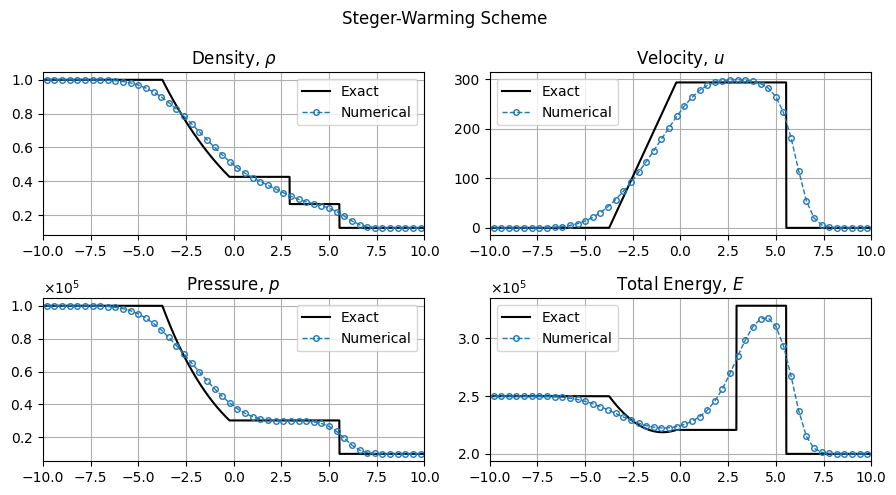

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(9,5))
axes = axes.flatten()
columns_to_plot = ["density", "velocity", "pressure", "total_energy"]
titles = [r"Density, $\rho$", r"Velocity, $u$", r"Pressure, $p$", r"Total Energy, $E$"]
for i, var in enumerate(columns_to_plot):
    ax = axes[i]
    ax.plot(exact_df["x"], exact_df[var], label="Exact", color="black")
    if var in results_df.columns:
        ax.plot(results_df["x"], results_df[var], 'o--', markersize=4, markerfacecolor='none',linewidth=1, label="Numerical")
    ax.set_title(titles[i])
    ax.legend()
    ax.grid()
    if exact_df[var].max() > 1e3:
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_xlim(XMIN, XMAX)
fig.suptitle("Steger-Warming Scheme")
fig.tight_layout()